In [1]:
using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf



In [2]:
using JLD2
using Printf

data_dir = joinpath(@__DIR__, "data")

# all_data[truncation][sigma] = loaded_data_dict 
all_data = Dict{Float64, Dict{Float64, Any}}() 

sigma_values = [0.0, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 2e-6, 3e-6, 4e-6, 5e-6, 1e-5, 1e-4, 1e-3, 1e-2, 2e-2, 1e-1, 2e-1, 5e-1, 7e-1, 1.0, 1.5, 2.0, 3.0, 5.0]
trunc_values = [1e-16, 1e-15, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8] 

for trunc in trunc_values
    all_data[trunc] = Dict{Float64, Any}()
    
    for σ in sigma_values
        trunc_str = @sprintf("%.1e", trunc)
        
        # Explicitly format the clean case string to match the get_data_clean.jl output
        if σ == 0.0
            sigma_str = "0.0e+00"
        else
            sigma_str = @sprintf("%.1e", σ)
        end

        file_name = "data_fid_$(trunc_str)_$(sigma_str).jld2" 
        file_path = joinpath(data_dir, file_name) 
        
        if isfile(file_path) 
            try
                data = load(file_path)
                all_data[trunc][σ] = data 
                println("Successfully loaded: Trunc=$trunc_str, σ=$sigma_str")
            catch e
                println("ERROR loading file: $file_name -> $e")
            end
        else
            println("File not found: $file_name") 
        end
    end
end


File not found: data_fid_1.0e-16_0.0e+00.jld2
Successfully loaded: Trunc=1.0e-16, σ=5.0e-07
Successfully loaded: Trunc=1.0e-16, σ=6.0e-07
Successfully loaded: Trunc=1.0e-16, σ=7.0e-07
Successfully loaded: Trunc=1.0e-16, σ=8.0e-07
Successfully loaded: Trunc=1.0e-16, σ=9.0e-07
Successfully loaded: Trunc=1.0e-16, σ=1.0e-06
Successfully loaded: Trunc=1.0e-16, σ=2.0e-06
Successfully loaded: Trunc=1.0e-16, σ=3.0e-06
Successfully loaded: Trunc=1.0e-16, σ=4.0e-06
Successfully loaded: Trunc=1.0e-16, σ=5.0e-06
Successfully loaded: Trunc=1.0e-16, σ=1.0e-05
Successfully loaded: Trunc=1.0e-16, σ=1.0e-04
Successfully loaded: Trunc=1.0e-16, σ=1.0e-03
Successfully loaded: Trunc=1.0e-16, σ=1.0e-02
Successfully loaded: Trunc=1.0e-16, σ=2.0e-02
Successfully loaded: Trunc=1.0e-16, σ=1.0e-01
Successfully loaded: Trunc=1.0e-16, σ=2.0e-01
Successfully loaded: Trunc=1.0e-16, σ=5.0e-01
Successfully loaded: Trunc=1.0e-16, σ=7.0e-01
Successfully loaded: Trunc=1.0e-16, σ=1.0e+00
Successfully loaded: Trunc=1.0e-16

In [3]:
println(all_data[1e-16][5e-7])

Dict{String, Any}("s05_avg" => [0.6931471805599453, 0.9808293603623721, 1.1631510230633109, 1.2966824393567316, 1.402043032539284, 1.4890544177913327, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "fid_avg" => [1.0, 0.9999999999999833, 0.9999999999999698, 0.9999999999999751, 0.9999999999999737, 0.9999999999999754, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "energy_avg" => [-0.7500000149289343, -2.500000197244735, -5.249999719319543, -9.000000159985705, -13.749999621648461, -19.500000385212626, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "vn_err" => [0.0, 1.236975912219879e-7, 6.970473306496772e-8, 4.0706560168307

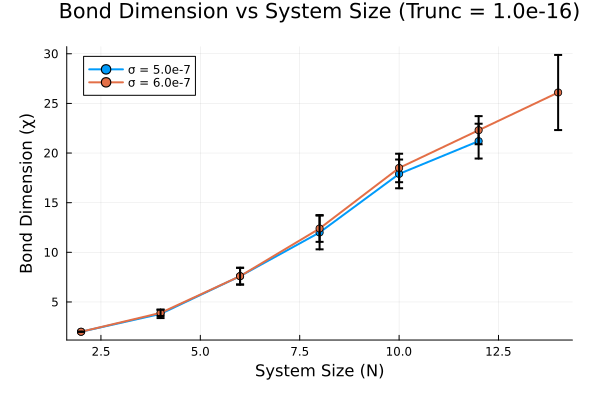

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd.png"

In [4]:
target_sigmas = [0.0, 5e-7, 6e-7] 
target_trunc = 1e-16

p_bd = plot(
    title = "Bond Dimension vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    # Flipped to match the new all_data[truncation][sigma] structure
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd.png"))

# Fidelity


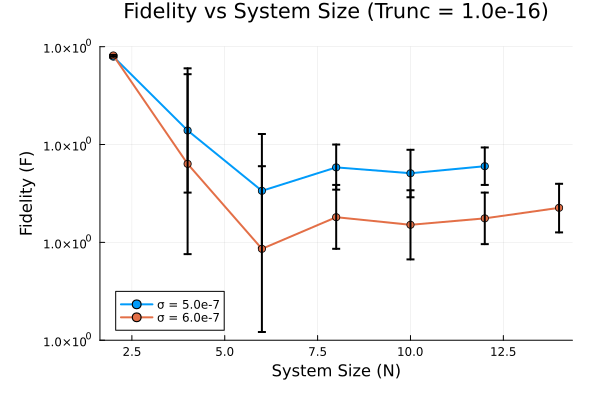

GKS: Possible loss of precision in routine SET_WINDOW


"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\fidelity.png"

In [5]:
target_sigmas = [5e-7, 6e-7] 
target_trunc = 1e-16

p_fid = plot(
    title = "Fidelity vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Fidelity (F)",
    legend = :bottomleft,  # Moved to bottom left so it doesn't cover data near F=1
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        # We use the bond dimension > 0 as a universal mask for "completed runs"
        mask = data["avg_arr"] .> 0 
        
        N_vals = N_full[mask]
        fid_avg = data["fid_avg"][mask]
        fid_err_full = data["fid_err"]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = fid_err_full[mask]
        end

        plot!(p_fid, N_vals, fid_avg, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_fid)
savefig(p_fid, joinpath("images", "fidelity.png"))

# Infidelity


In [6]:
# You likely don't want to plot 0.0 here since log10(0) is undefined
target_sigmas_infid = [5e-7, 6e-7] 
target_trunc = 1e-16

p_infid = plot(
    title = "Infidelity vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Infidelity (1 - F)",
    yscale = :log10,       # Crucial for infidelity plots!
    legend = :topleft,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas_infid
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        # Mask using bond dimension to grab only finished N values
        mask = data["avg_arr"] .> 0 
        
        N_vals = N_full[mask]
        infid_avg = data["infid_avg"][mask]
        infid_err_full = data["infid_err"]
        
        # Only plot if there's actual data to avoid log(0) errors
        if length(infid_avg) > 0
            plot!(p_infid, N_vals, infid_avg, 
                yerror = infid_err_full[mask],
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)
        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_infid)
savefig(p_infid, joinpath("images", "infidelity.png"))

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


LoadError: AssertionError: total_plotarea_horizontal > 0mm